In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prajwalbhamere/car-damage-severity-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'car-damage-severity-dataset' dataset.
Path to dataset files: /kaggle/input/car-damage-severity-dataset


In [2]:
!ls /kaggle/input/car-damage-severity-dataset/data3a

training  validation


In [3]:
import shutil
import os

source = os.path.join(path, "data3a")
destination = "/content/data3a"

# Remove existing copy if it exists
if os.path.exists(destination):
    shutil.rmtree(destination)

shutil.copytree(source, destination)

print("Dataset copied successfully!")

Dataset copied successfully!


In [4]:
!ls /content/data3a

training  validation


In [5]:
# ==============================
# Import Required Libraries
# ==============================

import os
import random
import warnings

import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

#Pytorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split

# Torchvision
from torchvision import datasets, transforms, models

#Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")


In [6]:
DATASET_ROOT = "/content/data3a"
TRAIN_DIR = os.path.join(DATASET_ROOT,"training")
VAL_DIR = os.path.join(DATASET_ROOT, "validation")

# Training Configuration
IMAGE_SIZE = 224,
BATCH_SIZE = 32,
NUM_CLASSES = 3

epochs = 35

SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", DEVICE)
print("Training Directory :", TRAIN_DIR)
print("Validation Directory :", VAL_DIR)

Device : cuda
Training Directory : /content/data3a/training
Validation Directory : /content/data3a/validation


In [7]:
train_dataset = datasets.ImageFolder(TRAIN_DIR)

val_dataset = datasets.ImageFolder(VAL_DIR)

print("Training Images:", len(train_dataset))

print("\nClasses")

print(train_dataset.classes)

print("\nClass Mapping")

print(train_dataset.class_to_idx)

Training Images: 1383

Classes
['01-minor', '02-moderate', '03-severe']

Class Mapping
{'01-minor': 0, '02-moderate': 1, '03-severe': 2}


In [8]:
# ============================================
# Inspect Dataset
# ============================================

image, label = train_dataset[0]

print("Image Type :", type(image))

print("Image Size :", image.size)

print("Label :", label)

print("Class :", train_dataset.classes[label])

Image Type : <class 'PIL.Image.Image'>
Image Size : (233, 217)
Label : 0
Class : 01-minor


In [9]:
# ============================================
# Dataset Summary
# ============================================

from collections import Counter

# Count images in each class
train_counts = Counter([label for _, label in train_dataset])
val_counts = Counter([label for _, label in val_dataset])

print("=" * 50)
print("TRAINING DATASET")
print("=" * 50)

for idx, class_name in enumerate(train_dataset.classes):
    print(f"{class_name:15s}: {train_counts[idx]} images")

print(f"\nTotal Training Images: {len(train_dataset)}")

print("\n" + "=" * 50)
print("VALIDATION DATASET")
print("=" * 50)

for idx, class_name in enumerate(val_dataset.classes):
    print(f"{class_name:15s}: {val_counts[idx]} images")

print(f"\nTotal Validation Images: {len(val_dataset)}")

TRAINING DATASET
01-minor       : 452 images
02-moderate    : 463 images
03-severe      : 468 images

Total Training Images: 1383

VALIDATION DATASET
01-minor       : 82 images
02-moderate    : 75 images
03-severe      : 91 images

Total Validation Images: 248


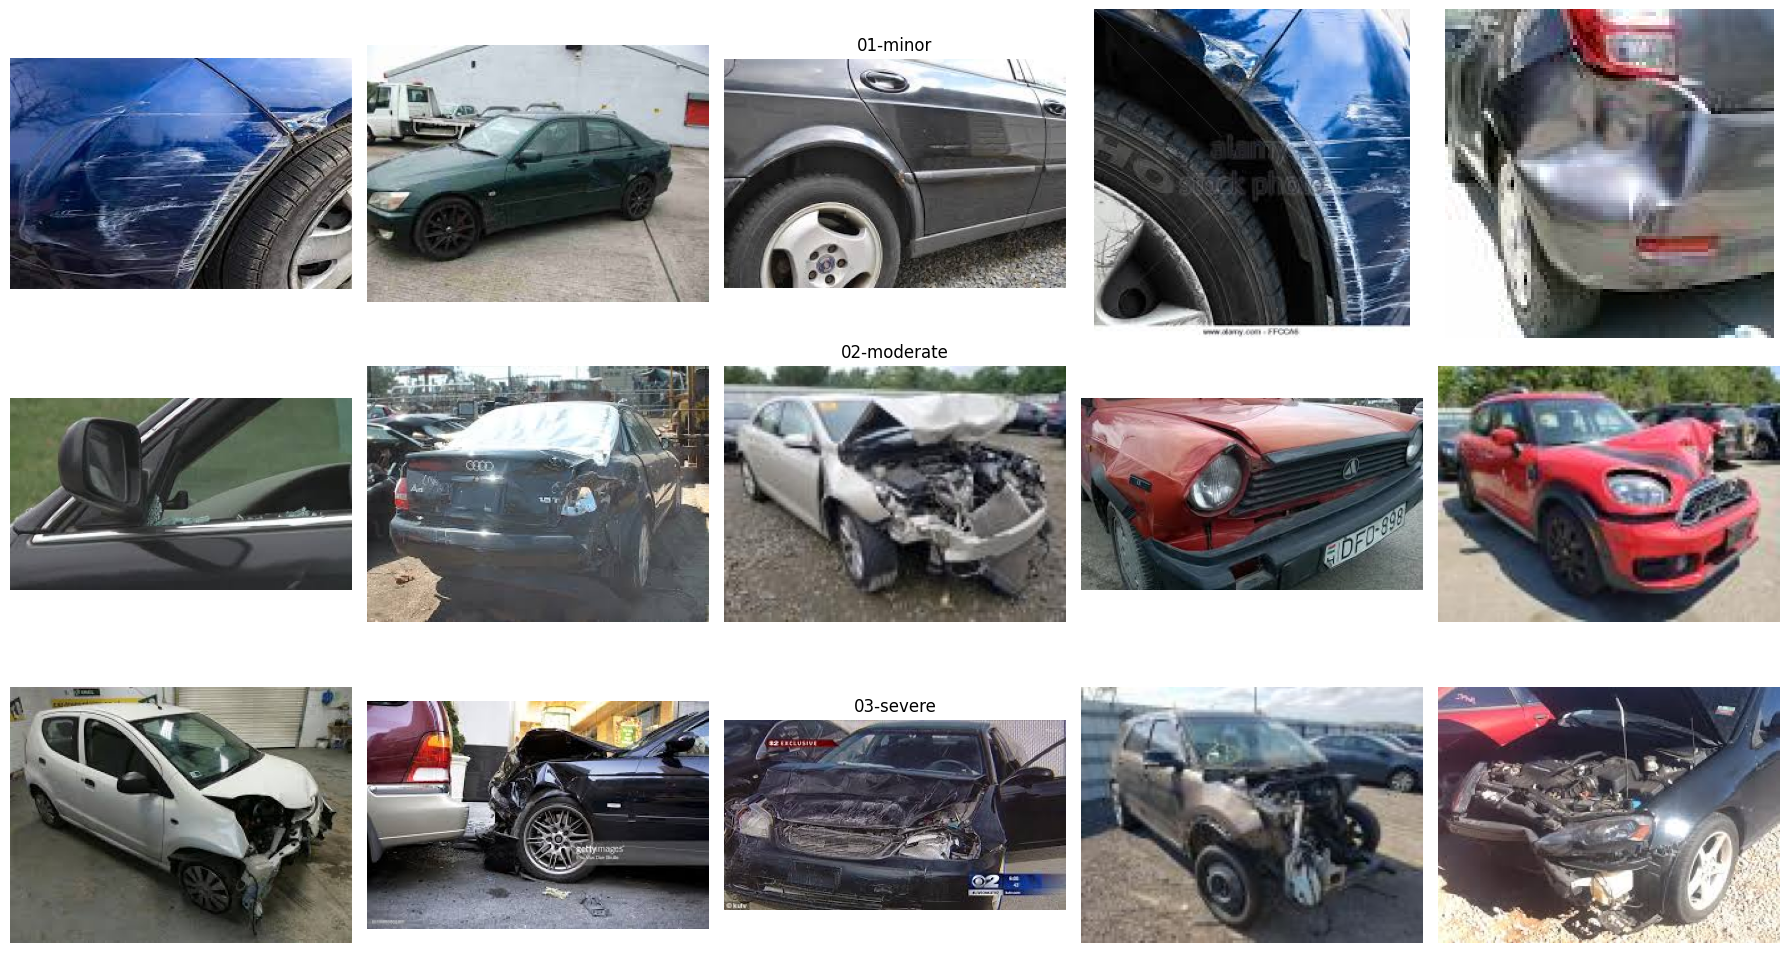

In [10]:
# ============================================
# Visualize Random Images from Each Class
# ============================================

classes = train_dataset.classes

fig, axes = plt.subplots(3, 5, figsize=(18, 10))

for class_idx, class_name in enumerate(classes):

    # Get image paths belonging to current class
    class_samples = [
        sample for sample in train_dataset.samples
        if sample[1] == class_idx
    ]

    # Select 5 random images
    selected_samples = random.sample(class_samples, 5)

    for j, (img_path, _) in enumerate(selected_samples):

        img = Image.open(img_path).convert("RGB")

        axes[class_idx, j].imshow(img)
        axes[class_idx, j].axis("off")

        if j == 2:
            axes[class_idx, j].set_title(class_name, fontsize=12)

plt.tight_layout()
plt.show()

In [11]:
widths = []
heights = []
aspect_ratios = []

for img_path, _ in train_dataset.samples:

  img = Image.open(img_path)

  w, h = img.size

  widths.append(w)
  heights.append(h)
  aspect_ratios.append(round(w / h , 2))

print("=" * 50)
print("IMAGE RESOLUTION STATISTICS")
print("=" * 50)

print(f"Minimum Width  : {min(widths)}")
print(f"Maximum Width  : {max(widths)}")
print(f"Average Width  : {np.mean(widths):.2f}")

print()

print(f"Minimum Height : {min(heights)}")
print(f"Maximum Height : {max(heights)}")
print(f"Average Height : {np.mean(heights):.2f}")

print()

print(f"Average Aspect Ratio : {np.mean(aspect_ratios):.2f}")


IMAGE RESOLUTION STATISTICS
Minimum Width  : 96
Maximum Width  : 411
Average Width  : 246.67

Minimum Height : 72
Maximum Height : 306
Average Height : 178.15

Average Aspect Ratio : 1.41


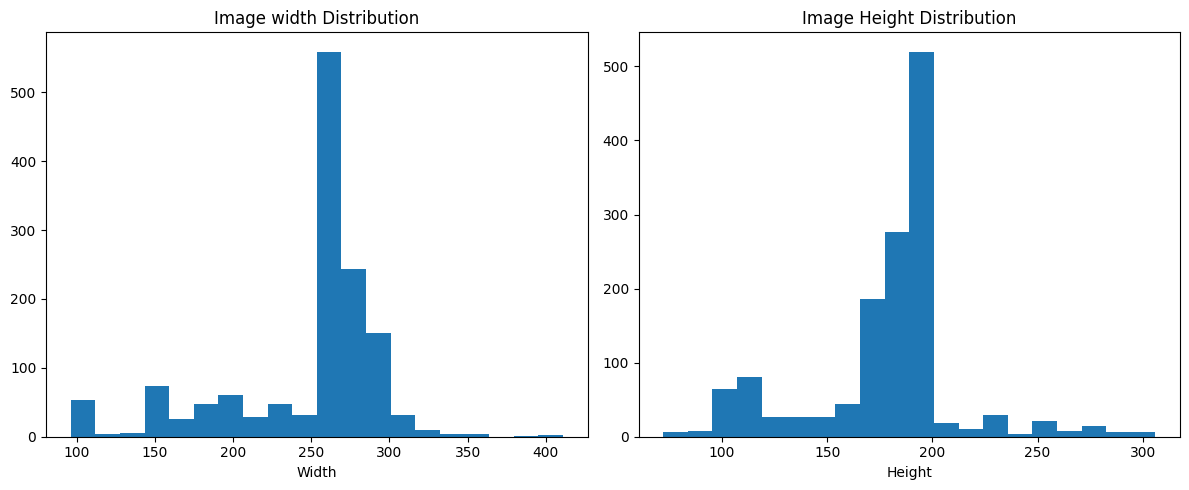

In [12]:
# ============================================
# Image Size Distribution
# ============================================

plt.figure(figsize = (12,5))

plt.subplot(1,2,1)
plt.hist(widths, bins = 20)
plt.title("Image width Distribution")
plt.xlabel("Width")

plt.subplot(1,2,2)
plt.hist(heights, bins = 20)
plt.title("Image Height Distribution")
plt.xlabel("Height")

plt.tight_layout()
plt.show()

In [13]:
# ============================================
# Image Transformations
# ============================================

from torchvision import transforms

# ImageNet normalization values
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([

    transforms.RandomResizedCrop(
        224,
        scale=(0.9,1.0)
    ),


    transforms.ToTensor(),

    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )

])

val_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )

])


In [14]:
# ============================
# Reload Dataset with Transforms
# ============================

train_dataset = datasets.ImageFolder(
    root = TRAIN_DIR,
    transform = train_transform
)

val_dataset = datasets.ImageFolder(
    root = VAL_DIR,
    transform = val_transform
)

print("Training Images :", len(train_dataset))
print("Validation Images :", len(val_dataset))

Training Images : 1383
Validation Images : 248


In [15]:
from collections import Counter

counts = Counter(label for _, label in train_dataset.samples)

for cls, idx in train_dataset.class_to_idx.items():
    print(cls, counts[idx])

01-minor 452
02-moderate 463
03-severe 468


In [16]:
train_loader = DataLoader(
    train_dataset,
    batch_size = 32,
    shuffle = True
)

val_loader = DataLoader(
    val_dataset,
    batch_size = 32,
    shuffle = False
)

print("Train batches :", len(train_loader))
print("Validation batches :", len(val_loader))


Train batches : 44
Validation batches : 8


In [17]:
# ============================================
# Verify DataLoader
# ============================================


images, labels = next(iter(train_loader))

print("Image Batch Shape :", images.shape)
print("Label Shape       :", labels.shape)

print("Image Data Type   :", images.dtype)
print("Label Data Type   :", labels.dtype)

Image Batch Shape : torch.Size([32, 3, 224, 224])
Label Shape       : torch.Size([32])
Image Data Type   : torch.float32
Label Data Type   : torch.int64


In [18]:
# ============================================
# Load Pretrained ResNet18
# ============================================

from torchvision.models import (
    vit_b_16,
    ViT_B_16_Weights
)

weights = ViT_B_16_Weights.DEFAULT

model = vit_b_16(weights = weights)

print(model)

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [19]:
in_features = model.heads[0].in_features
model.heads = nn.Sequential(
    nn.Linear(in_features,64),
    nn.ReLU(inplace = True),
    nn.Dropout(0.4),

    nn.Linear(64,32),
    nn.ReLU(inplace = True),
    nn.Dropout(0.3),

    nn.Linear(32, NUM_CLASSES)
)

model = model.to(DEVICE)

In [20]:
# Freeze feature extractor
for param in model.parameters():
    param.requires_grad = False

for param in model.heads.parameters():
  param.requires_grad = True

In [21]:
total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters      : {total_params:,}")
print(f"Trainable Parameters  : {trainable_params:,}")
print(f"Frozen Parameters     : {total_params-trainable_params:,}")

Total Parameters      : 85,850,051
Trainable Parameters  : 51,395
Frozen Parameters     : 85,798,656


In [22]:
import torch.optim as optim

#Loss Function
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(

    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),

    lr=1e-4
)

In [23]:
best_val_loss = float('inf')
patience = 10
counter = 0

In [24]:

for epoch in range(epochs):
  model.train()
  train_loss = 0

  for images,labels in train_loader:
    images = images.to(DEVICE)
    labels = labels.to(DEVICE)

    outputs = model(images)
    loss = criterion(outputs,labels)

    loss.backward()
    optimizer.step()

    optimizer.zero_grad()

    train_loss += loss.item()

  avg_train_loss = train_loss/len(train_loader)

  with torch.no_grad():
    model.eval()
    val_loss = 0

    for images,labels in val_loader:
      images = images.to(DEVICE)
      labels = labels.to(DEVICE)

      outputs = model(images)
      loss = criterion(outputs,labels)

      val_loss += loss.item()

  avg_val_loss = val_loss/len(val_loader)

  print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {avg_train_loss:.6f} "
          f"Val Loss: {avg_val_loss:.6f}")

  if val_loss < best_val_loss:
    best_val_loss = val_loss
    counter = 0
    torch.save(model.state_dict(), "best_model.pth")
  else:
    counter += 1
    if counter >= patience:
      print("Early Stopping Trigerred")
      break

Epoch [1/35] Train Loss: 1.099669 Val Loss: 1.085992
Epoch [2/35] Train Loss: 1.073667 Val Loss: 1.044196
Epoch [3/35] Train Loss: 1.039480 Val Loss: 0.982367
Epoch [4/35] Train Loss: 1.004420 Val Loss: 0.920801
Epoch [5/35] Train Loss: 0.962578 Val Loss: 0.866165
Epoch [6/35] Train Loss: 0.914235 Val Loss: 0.814854
Epoch [7/35] Train Loss: 0.885644 Val Loss: 0.773503
Epoch [8/35] Train Loss: 0.848538 Val Loss: 0.735781
Epoch [9/35] Train Loss: 0.826406 Val Loss: 0.710782
Epoch [10/35] Train Loss: 0.818153 Val Loss: 0.698500
Epoch [11/35] Train Loss: 0.799346 Val Loss: 0.679861
Epoch [12/35] Train Loss: 0.779781 Val Loss: 0.656959
Epoch [13/35] Train Loss: 0.775687 Val Loss: 0.654631
Epoch [14/35] Train Loss: 0.758881 Val Loss: 0.639086
Epoch [15/35] Train Loss: 0.754443 Val Loss: 0.633018
Epoch [16/35] Train Loss: 0.730457 Val Loss: 0.625476
Epoch [17/35] Train Loss: 0.713529 Val Loss: 0.620510
Epoch [18/35] Train Loss: 0.711496 Val Loss: 0.608965
Epoch [19/35] Train Loss: 0.692576 Va

In [25]:
model.load_state_dict(torch.load("best_model.pth"))

<All keys matched successfully>

In [26]:
# ============================================
# Prediction on Validation Dataset
# ============================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

y_true = []
y_pred = []

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(DEVICE)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

In [27]:
accuracy = accuracy_score(y_true, y_pred)

print(f"Validation Accuracy : {accuracy*100:.2f}%")

Validation Accuracy : 72.58%


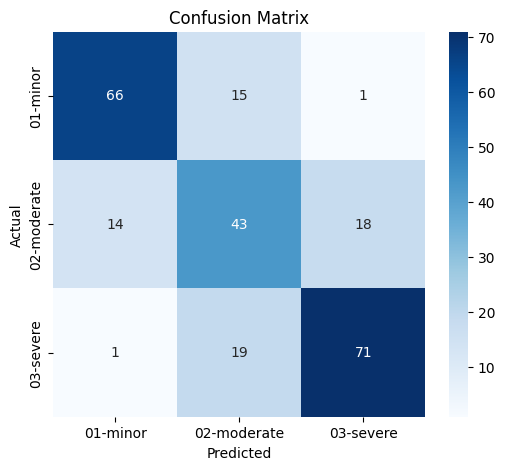

In [28]:
# ============================================
# Confusion Matrix
# ============================================

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [29]:
print(classification_report(
    y_true,
    y_pred,
    target_names=train_dataset.classes
))

              precision    recall  f1-score   support

    01-minor       0.81      0.80      0.81        82
 02-moderate       0.56      0.57      0.57        75
   03-severe       0.79      0.78      0.78        91

    accuracy                           0.73       248
   macro avg       0.72      0.72      0.72       248
weighted avg       0.73      0.73      0.73       248



In [35]:
!pip install -q langchain langchain-community langchain-text-splitters faiss-cpu sentence-transformers pypdf

In [36]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter   # ← changed
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

In [37]:
# ============================================================
# RAG Policy Knowledge Base (Corrected)
# ============================================================

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS


PDF_PATH = "/content/AI_Insurance_RAG_Policy_Knowledge_Base.pdf"

loader = PyPDFLoader(PDF_PATH)
pages = loader.load()
print(f"Loaded {len(pages)} pages from PDF")

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=80,
    separators=["\n\n", "\n", ".", " "]
)

chunks = text_splitter.split_documents(pages)
print(f"Created {len(chunks)} chunks")

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

vectorstore = FAISS.from_documents(chunks, embeddings)

print("✅ RAG Vector Store created successfully!")

Loaded 3 pages from PDF
Created 15 chunks


/tmp/ipykernel_5676/2128473580.py:28: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ RAG Vector Store created successfully!


In [ ]:
# ============================================================
# RAG Prerequisite Definitions
# ============================================================
# Defines all names required by rag_claim_estimator() below.
# Class mapping verified from notebook Cell 6 output:
#   {'01-minor': 0, '02-moderate': 1, '03-severe': 2}
#
# ARCHITECTURE NOTE:
#   Notebook  = ViT severity classification + RAG policy retrieval (demo).
#   Web app   = ViT severity classification + PostgreSQL policy rules +
#               deterministic claim calculation (Backend/app/services/).
#   The web application backend does NOT use FAISS or LangChain.
# ============================================================

import torch.nn.functional as F

# Class index to internal severity key (matches training class order)
IDX_TO_SEVERITY = {0: 'minor', 1: 'moderate', 2: 'severe'}

# Internal key to display label
SEVERITY_TO_NAME = {'minor': 'Minor', 'moderate': 'Moderate', 'severe': 'Severe'}

# ============================================================
# Prototype policy rules from RAG Policy Knowledge Base document.
# Values taken exactly from the document (P001-P006).
# annual_premium omitted — not specified in the document.
# ============================================================
POLICY_RULES = {
    'P001': {'name': 'Basic Comprehensive',    'minor': 80, 'moderate': 75, 'severe': 70, 'deductible': 5000,  'max_claim': 100000},
    'P002': {'name': 'Standard Comprehensive', 'minor': 85, 'moderate': 80, 'severe': 75, 'deductible': 5000,  'max_claim': 150000},
    'P003': {'name': 'Premium Comprehensive',  'minor': 90, 'moderate': 90, 'severe': 85, 'deductible': 2000,  'max_claim': 300000},
    'P004': {'name': 'Zero Depreciation',      'minor': 95, 'moderate': 95, 'severe': 90, 'deductible': 2000,  'max_claim': 500000},
    'P005': {'name': 'Budget Own-Damage',      'minor': 75, 'moderate': 70, 'severe': 65, 'deductible': 7500,  'max_claim': 100000},
    'P006': {'name': 'Enhanced Protection',    'minor': 90, 'moderate': 88, 'severe': 85, 'deductible': 3000,  'max_claim': 400000},
}


def estimate_claim(severity: str, policy_id: str, repair_cost: float = None) -> dict:
    """
    Deterministic 8-step claim calculation from RAG Policy Knowledge Base.

    severity    : internal key from IDX_TO_SEVERITY ('minor'/'moderate'/'severe')
    policy_id   : e.g. 'P003'
    repair_cost : customer-submitted repair estimate (Option B).
                  If None, a midpoint of the documented prototype range is used
                  as a notebook-only fallback. In the web app, the customer
                  always provides claimed_amount at claim submission.
    """
    SEVERITY_RANGES = {
        'minor':    (5000,  20000),
        'moderate': (20000, 75000),
        'severe':   (75000, 250000),
    }
    if repair_cost is None:
        low, high = SEVERITY_RANGES[severity]
        repair_cost = (low + high) / 2  # notebook-only fallback

    rules = POLICY_RULES.get(policy_id)
    if not rules:
        raise ValueError(f'Unknown policy_id: {policy_id}. Valid: {list(POLICY_RULES.keys())}')

    coverage_pct = rules[severity]
    deductible   = rules['deductible']
    max_claim    = rules['max_claim']

    gross_covered = repair_cost * (coverage_pct / 100)   # Step 5
    preliminary   = gross_covered - deductible            # Step 6
    preliminary   = max(preliminary, 0)                   # Step 7
    final_claim   = min(preliminary, max_claim)           # Step 8

    return {
        'policy_id':         policy_id,
        'policy_name':       rules['name'],
        'severity':          SEVERITY_TO_NAME[severity],
        'repair_cost':       repair_cost,
        'coverage_pct':      coverage_pct,
        'gross_covered':     round(gross_covered, 2),
        'deductible':        deductible,
        'preliminary_claim': round(preliminary, 2),
        'max_claim':         max_claim,
        'estimated_claim':   round(final_claim, 2),
        'capped_by_max':     preliminary > max_claim,
    }


def print_claim_report(result: dict) -> None:
    """Print a formatted claim calculation report."""
    print()
    print('=' * 60)
    print('CLAIM CALCULATION  [Prototype — not real insurance]')
    print('=' * 60)
    print(f"  Policy         : {result['policy_id']} - {result['policy_name']}")
    print(f"  Severity       : {result['severity']}")
    print(f"  Repair Estimate: Rs{result['repair_cost']:,.0f}  (customer claimed amount)")
    print(f"  Coverage %     : {result['coverage_pct']}%")
    print(f"  Gross Covered  : Rs{result['gross_covered']:,.2f}")
    print(f"  Deductible     : Rs{result['deductible']:,.0f}")
    print(f"  Preliminary    : Rs{result['preliminary_claim']:,.2f}")
    print(f"  Max Claim Cap  : Rs{result['max_claim']:,.0f}")
    suffix = '  <- capped at maximum' if result['capped_by_max'] else ''
    print(f"  ESTIMATED CLAIM: Rs{result['estimated_claim']:,.2f}{suffix}")
    print('=' * 60)
    print('Note: ViT determines severity only.')
    print('      Calculation is a deterministic business rule.')
    print('      Claims Officer makes the final approval decision.')
    print('=' * 60)


print('Prerequisite definitions loaded:')
print(f'  IDX_TO_SEVERITY  : {IDX_TO_SEVERITY}')
print(f'  SEVERITY_TO_NAME : {SEVERITY_TO_NAME}')
print(f'  POLICY_RULES     : {list(POLICY_RULES.keys())}')
print('  estimate_claim() and print_claim_report() defined.')


In [38]:
def retrieve_policy_info(severity: str, policy_id: str = None, k: int = 4):
    """
    Retrieve relevant policy rules based on severity (and optional policy ID)
    """
    if policy_id:
        query = f"Policy {policy_id} coverage percentage for {severity} damage deductible maximum claim"
    else:
        query = f"coverage percentage for {severity} damage, deductible and maximum claim amount"

    docs = vectorstore.similarity_search(query, k=k)

    print("\n" + "="*60)
    print(f"RAG Retrieved Rules for → {severity.upper()} damage")
    if policy_id:
        print(f"Focusing on Policy: {policy_id}")
    print("="*60)

    for i, doc in enumerate(docs, 1):
        print(f"\n[Chunk {i}]")
        print(doc.page_content.strip())
        print("-"*50)

    return docs

In [ ]:
def rag_claim_estimator(
    model,
    image_path: str,
    policy_id: str = "P003",
    repair_cost: float = None,
    device=DEVICE
):
    """
    Complete RAG pipeline:
    1. ViT predicts severity
    2. RAG retrieves relevant policy rules
    3. Estimate claim amount
    """

    # ---------- A. ViT Prediction ----------
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(input_tensor)
        probs = F.softmax(outputs, dim=1)
        confidence, pred_idx = torch.max(probs, 1)

    severity = IDX_TO_SEVERITY[pred_idx.item()]
    conf = confidence.item()

    print(f"\nViT Prediction: {SEVERITY_TO_NAME[severity]}  |  Confidence: {conf*100:.1f}%")

    retrieved_docs = retrieve_policy_info(severity=severity, policy_id=policy_id)

    result = estimate_claim(
        severity=severity,
        policy_id=policy_id,
        repair_cost=repair_cost
    )

    print_claim_report(result)

    return {
        "severity": severity,
        "confidence": conf,
        "retrieved_docs": retrieved_docs,
        "claim_result": result
    }

In [40]:
# Example usage
result = rag_claim_estimator(
    model = model,
    image_path = "/content/usman-malik-xlxeGeh1DY4-unsplash.jpg",
    policy_id = "P004"
)


ViT Prediction: Moderate  |  Confidence: 66.4%

RAG Retrieved Rules for → MODERATE damage
Focusing on Policy: P004

[Chunk 1]
claim ■1,50,000. Pre-existing damage and intentional damage are excluded.
P003 — Premium Comprehensive
Higher coverage for accidental damage. Minor: 90%. Moderate: 90%. Severe: 85%. Deduct ■2,000. Maximum claim
■3,00,000. Requires valid policy coverage at the time of loss.
P004 — Zero Depreciation
For this prototype, approved repair costs are reimbursed at 95% for Minor and Moderate damage and 90% for Severe
--------------------------------------------------

[Chunk 2]
damage. Deduct ■2,000. Maximum claim ■5,00,000. The prototype treats this as reduced depreciation impact; real
zero-depreciation terms vary by insurer.
P005 — Budget Own-Damage
Lower-cost own-damage coverage. Minor: 75%. Moderate: 70%. Severe: 65%. Deduct ■7,500. Maximum claim
■1,00,000. Intended for prototype comparison only.
P006 — Enhanced Protection
Extended accidental-damage coverage. Minor: